# 03 — Computational Modelling

Analysis code for: *Test-Retest Reliability of a Pavlovian Go/No-Go Task with a Controllability Manipulation*

**Outputs:**
- Table 4: Model comparison (PSIS-LOO-CV)
- Table 5: Group-level parameter estimates (M4)
- Figure S1: Convergent validity — model-free vs model-based measures
- Figure S4A: Posterior predictive checks — all models
- Figure S4B: Posterior predictive checks — M4
- Figure 5A: Group-level parameter estimates
- Figure 5B: Split-half reliability
- Figure 5C: Test-retest reliability
- Between-session parameter comparison

> **Prerequisites:** Stan model fitting must be completed first. Results are expected in `stan_results/s1/` and `stan_results/s2/`.

## 1 — Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from pandas import DataFrame, read_csv, concat
from matplotlib.lines import Line2D
from sklearn.metrics import accuracy_score

# Directories
ANALYSIS_DIR = os.getcwd()
DATA_DIR     = os.path.join(ANALYSIS_DIR, 'data')
RESULTS_DIR  = os.path.join(ANALYSIS_DIR, 'stan_results')
FIG_DIR      = os.path.join(ANALYSIS_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Aesthetics
labelcolor = '#505050'
tickcolor  = '#606060'
axiscolor  = '#d3d3d3'
COLOR_REW  = '#234f81'
COLOR_PUN  = '#812623'
COLOR_AVG  = '#505050'

sns.set_theme(style='ticks', context='notebook', font_scale=1.2)

# Parameters
models      = ['pgng_m1', 'pgng_m2', 'pgng_m3', 'pgng_m4']
sessions    = ['s1', 's2']
session_map = {'s1': 1, 's2': 2}
MODEL       = 'pgng_m4'

params_order = ['b1', 'b2', 'a1', 'a2', 'b3', 'b4', 'd1', 'd2', 'c1']
param_labels = {
    'b1': r'$\beta_+$', 'b2': r'$\beta_-$',
    'b3': r'$\tau_+$',  'b4': r'$\tau_-$',
    'a1': r'$\eta_+$',  'a2': r'$\eta_-$',
    'd1': r'$\delta_+$','d2': r'$\delta_-$',
    'c1': r'$\xi$',
}
param_names = {
    'b1': 'β+', 'b2': 'β−', 'b3': 'τ+', 'b4': 'τ−',
    'a1': 'η+', 'a2': 'η−', 'd1': 'δ+', 'd2': 'δ−', 'c1': 'ξ'
}
PARAM_COLOR = {
    'b1': COLOR_REW, 'b2': COLOR_PUN,
    'a1': COLOR_REW, 'a2': COLOR_PUN,
    'b3': COLOR_REW, 'b4': COLOR_PUN,
    'd1': COLOR_REW, 'd2': COLOR_PUN,
    'c1': 'k',
}

GROUPS = [
    ('Outcome sensitivity (β+, β−)',        ['b1', 'b2']),
    ('Learning rates (η+, η−)',             ['a1', 'a2']),
    ('Approach/avoidance bias (τ+, τ−)',    ['b3', 'b4']),
    ('Controllability modulation (δ+, δ−)', ['d1', 'd2']),
    ('Lapse rate (ξ)',                      ['c1']),
]

def get_group_ci(samples, param):
    col = f'{param}_mu'
    if col not in samples.columns:
        return np.nan, np.nan, np.nan
    vals = samples[col].values
    return np.mean(vals), np.percentile(vals, 2.5), np.percentile(vals, 97.5)

def get_reliability(rel_df, param, rtype, group=0):
    sub = rel_df[(rel_df['Param']==param) &
                 (rel_df['Type']==rtype) &
                 (rel_df['Group']==group)]
    if len(sub) == 0:
        return np.nan, np.nan, np.nan
    return sub['Mean'].values[0], sub['2.5%'].values[0], sub['97.5%'].values[0]

print('Setup complete.')

Setup complete.


## 2 — Load Stan Results

In [2]:
# Load samples and reliability
samp_s1 = read_csv(os.path.join(RESULTS_DIR, 's1', f'{MODEL}.tsv.gz'), sep='\t', compression='gzip')
samp_s2 = read_csv(os.path.join(RESULTS_DIR, 's2', f'{MODEL}.tsv.gz'), sep='\t', compression='gzip')
rel     = read_csv(os.path.join(RESULTS_DIR, f'{MODEL}_reliability.csv'))

print(f'S1 samples: {samp_s1.shape}')
print(f'S2 samples: {samp_s2.shape}')
print(f'Reliability params: {rel.Param.unique()}')
print(f'Reliability types:  {rel.Type.unique()}')

S1 samples: (5000, 244)
S2 samples: (5000, 244)
Reliability params: ['b1' 'b2' 'b3' 'b4' 'a1' 'a2' 'd1' 'd2' 'c1']
Reliability types:  ['sh' 'trt']


## 3 — Figure S1: Convergent Validity

In [3]:
from scipy.stats import spearmanr

# Load behavioural data
data   = read_csv(os.path.join(DATA_DIR, 'pgng.csv'))
reject = read_csv(os.path.join(DATA_DIR, 'reject.csv'))
data   = data[data.subject.isin(reject.query('reject==0').subject)].reset_index(drop=True)

subj_map           = {s: i+1 for i, s in enumerate(sorted(data['subject'].unique()))}
data['subject_id'] = data['subject'].map(subj_map)
data['prev_sham']  = data.groupby(['subject','session','stimulus'])['sham'].transform(lambda x: x.shift(1))
data.loc[data['exposure']==1, 'prev_sham'] = np.nan

# Compute model-free indices
mf_results = []
for (subj, sess), grp in data.groupby(['subject_id', 'session']):
    acc     = grp.groupby('robot_type')['accuracy'].mean()
    acc_con = grp[grp['controllability']=='controllable'].groupby('robot_type')['accuracy'].mean()
    acc_unc = grp[grp['controllability']=='uncontrollable'].groupby('robot_type')['accuracy'].mean()

    approach_bias   = acc.get('gw', np.nan)   - acc.get('ngw', np.nan)
    avoidance_bias  = acc.get('ngal', np.nan) - acc.get('gal', np.nan)
    go_bias         = (acc.get('gw', np.nan) + acc.get('gal', np.nan)) / 2 - \
                      (acc.get('ngw', np.nan) + acc.get('ngal', np.nan)) / 2
    pav_bias        = (acc.get('gw', np.nan) + acc.get('ngal', np.nan)) / 2 - \
                      (acc.get('ngw', np.nan) + acc.get('gal', np.nan)) / 2
    ctrl_effect_rew = (acc_unc.get('gw', np.nan)   - acc_unc.get('ngw', np.nan)) - \
                      (acc_con.get('gw', np.nan)   - acc_con.get('ngw', np.nan))
    ctrl_effect_pun = (acc_unc.get('ngal', np.nan) - acc_unc.get('gal', np.nan)) - \
                      (acc_con.get('ngal', np.nan) - acc_con.get('gal', np.nan))

    ctrl_win = grp[(grp['controllability']=='controllable') & (grp['valence']=='win')]
    sub_fb   = ctrl_win[ctrl_win['prev_sham'].isin([0.0, 1.0])]
    fb = (sub_fb[sub_fb['prev_sham']==0]['accuracy'].mean() -
          sub_fb[sub_fb['prev_sham']==1]['accuracy'].mean()) if len(sub_fb) > 0 else np.nan

    mf_results.append({
        'subject': subj, 'session': sess,
        'approach_bias': approach_bias, 'avoidance_bias': avoidance_bias,
        'ctrl_rew': ctrl_effect_rew, 'ctrl_pun': ctrl_effect_pun,
        'feedback_sens': fb, 'go_bias': go_bias, 'pav_bias': pav_bias,
    })

mf = pd.DataFrame(mf_results)

# Extract model-based parameters
mb_list = []
for session, sess_str in [(1,'s1'),(2,'s2')]:
    samples = read_csv(os.path.join(RESULTS_DIR, sess_str, f'{MODEL}.tsv.gz'),
                       sep='\t', compression='gzip')
    for param in ['b1','b2','b3','b4','a1','a2','d1','d2']:
        cols  = [c for c in samples.columns if c.startswith(f'{param}[')]
        if not cols: continue
        means = samples[cols].mean(axis=0).values
        for i, m in enumerate(means):
            mb_list.append({'subject': i+1, 'session': session, 'param': param, 'value': m})

mb     = pd.DataFrame(mb_list).pivot_table('value',['subject','session'],'param').reset_index()
mb.columns.name = None
merged = mf.merge(mb, on=['subject','session'])
print(f'Merged shape: {merged.shape}')

# Compute Spearman correlations
mf_cols   = ['approach_bias','avoidance_bias','ctrl_rew','ctrl_pun','feedback_sens','go_bias','pav_bias']
mf_labels = ['Approach bias (reward)','Avoidance bias (punishment)',
             'Controllability effect (reward)','Controllability effect (punishment)',
             'Feedback sensitivity','Go bias (overall)','Pavlovian bias (overall)']
mb_cols   = ['b1','b2','b3','b4','a1','a2','d1','d2']
mb_labels = [r'$\beta_+$',r'$\beta_-$',r'$\tau_+$',r'$\tau_-$',
             r'$\eta_+$',r'$\eta_-$',r'$\delta_+$',r'$\delta_-$']

corr_matrix = pd.DataFrame(index=mf_labels, columns=mb_labels, dtype=float)
for mf_col, mf_lab in zip(mf_cols, mf_labels):
    for mb_col, mb_lab in zip(mb_cols, mb_labels):
        valid = merged[[mf_col, mb_col]].dropna()
        if len(valid) > 3:
            r, _ = spearmanr(valid[mf_col], valid[mb_col])
            corr_matrix.loc[mf_lab, mb_lab] = round(r, 2)

print('Correlation matrix:')
print(corr_matrix)

Merged shape: (48, 17)
Correlation matrix:
                                     $\beta_+$  $\beta_-$  $\tau_+$  $\tau_-$  \
Approach bias (reward)                   -0.54      -0.46      0.81     -0.17   
Avoidance bias (punishment)              -0.42      -0.26      0.02     -0.93   
Controllability effect (reward)           0.21      -0.08     -0.17      0.10   
Controllability effect (punishment)      -0.08      -0.17      0.03      0.17   
Feedback sensitivity                      0.48       0.32     -0.34      0.41   
Go bias (overall)                         0.16      -0.02      0.39      0.70   
Pavlovian bias (overall)                 -0.56      -0.50      0.62     -0.56   

                                     $\eta_+$  $\eta_-$  $\delta_+$  \
Approach bias (reward)                  -0.02     -0.12        0.21   
Avoidance bias (punishment)             -0.28     -0.25        0.02   
Controllability effect (reward)          0.16      0.41        0.78   
Controllability effect (

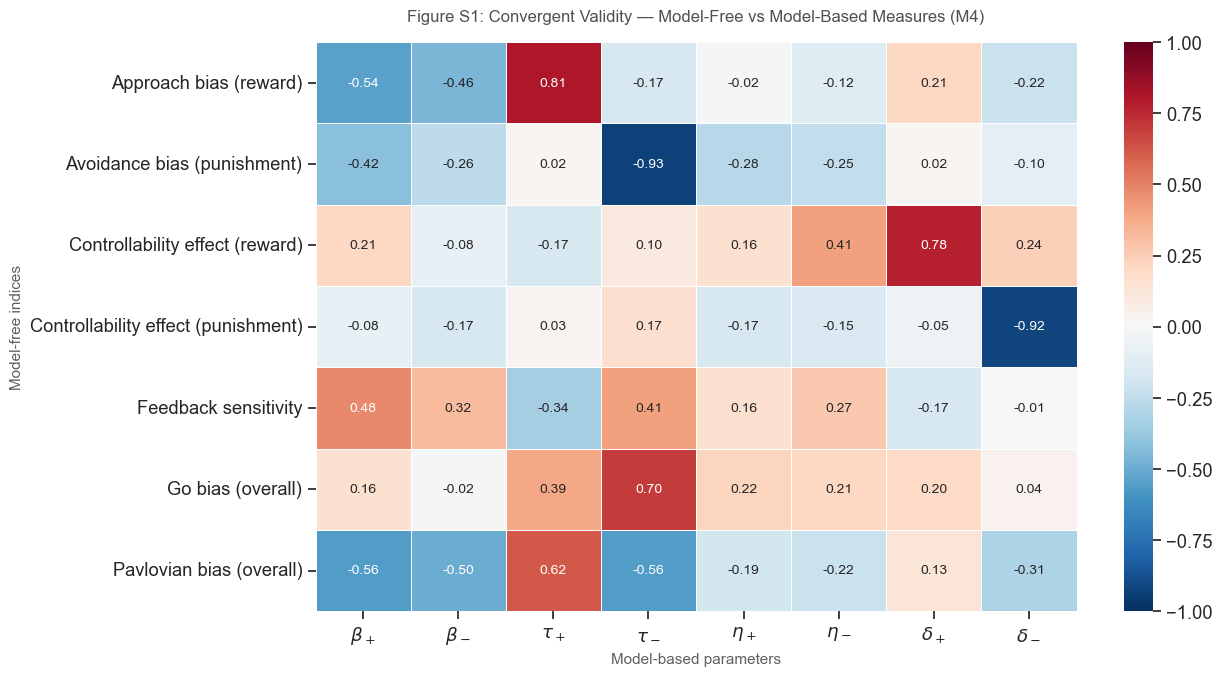

Saved figS1


In [4]:
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')

sns.heatmap(corr_matrix.astype(float),
            annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 10})

ax.set_title('Figure S1: Convergent Validity — Model-Free vs Model-Based Measures (M4)',
             color=labelcolor, fontsize=12, pad=15)
ax.set_xlabel('Model-based parameters', color=tickcolor, fontsize=11)
ax.set_ylabel('Model-free indices', color=tickcolor, fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'figS1_convergent_validity.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'figS1_convergent_validity.pdf'), bbox_inches='tight')
plt.show()
print('Saved figS1')

## 4 — Convergence Diagnostics

In [5]:
diagnostics = []
for m in models:
    for s in sessions:
        samples = read_csv(os.path.join(RESULTS_DIR, s, f'{m}.tsv.gz'), sep='\t', compression='gzip')
        summary = read_csv(os.path.join(RESULTS_DIR, s, f'{m}_summary.tsv'), sep='\t', index_col=0)
        ppc     = read_csv(os.path.join(RESULTS_DIR, s, f'{m}_ppc.csv'))
        ppc     = ppc[~np.isinf(ppc.k_u)]

        diagnostics.append(dict(
            model      = m,
            session    = s,
            divergence = samples.divergent__.sum(),
            rhat       = len(summary.query('R_hat >= 1.02')),
            n_eff      = len(summary.query('ESS_bulk < 400')),
            p_loo      = np.round(ppc.pwaic.sum(), 1),
            pk_bad     = np.round(np.sum(ppc.k_u > 0.7), 3)
        ))

diag_df = DataFrame(diagnostics).sort_values(['session','model']).set_index(['session','model'])
print('Convergence diagnostics:')
print(diag_df.to_string())

Convergence diagnostics:
                 divergence  rhat  n_eff  p_loo  pk_bad
session model                                          
s1      pgng_m1         0.0     0      0   16.2       0
        pgng_m2         0.0     0      0   22.0       0
        pgng_m3         0.0     0      0   18.0       0
        pgng_m4         0.0     0      0   23.9       0
s2      pgng_m1         0.0     0      0   18.1       0
        pgng_m2         0.0     0      0   24.2       0
        pgng_m3         0.0     0      0   19.8       1
        pgng_m4         0.0     8     12   26.8       1


## 4 — Table 4: Model Comparison (PSIS-LOO-CV)

In [6]:
loocv_results = []
for i, m in enumerate(models):
    ppc_all  = concat([read_csv(os.path.join(RESULTS_DIR, s, f'{m}_ppc.csv')) for s in sessions])
    ppc_win  = concat([read_csv(os.path.join(RESULTS_DIR, s, f'{MODEL}_ppc.csv')) for s in sessions])

    score = accuracy_score(ppc_all.choice, ppc_all.Y_hat > 0.5) * 100
    loo   = -2 * ppc_all.loo.sum()
    arr   = -2 * (ppc_win.loo - ppc_all.loo)
    mu    = np.sum(arr)
    se    = np.std(arr) * np.sqrt(len(arr))

    loocv_results.append(dict(
        Model   = f'M{i+1}',
        Score   = f'{score:.1f}%',
        LOOCV   = f'{loo:.1f}',
        Delta   = f'{mu:.1f} ({se:.1f})' if m != MODEL else '0.0 (—)'
    ))

table4 = DataFrame(loocv_results).set_index('Model')
print('Table 4: Model Comparison (PSIS-LOO-CV, collapsed across sessions)')
print(table4.to_string())

Table 4: Model Comparison (PSIS-LOO-CV, collapsed across sessions)
       Score     LOOCV          Delta
Model                                
M1     78.6%  -24195.4  -277.0 (14.8)
M2     79.0%  -24419.3    -53.1 (6.1)
M3     78.7%  -24260.8  -211.7 (13.9)
M4     79.2%  -24472.5        0.0 (—)


In [7]:
# Per-session breakdown
loocv_by_session = []
for i, m in enumerate(models):
    for s in sessions:
        ppc1 = read_csv(os.path.join(RESULTS_DIR, s, f'{m}_ppc.csv'))
        ppc2 = read_csv(os.path.join(RESULTS_DIR, s, f'{MODEL}_ppc.csv'))
        score = accuracy_score(ppc1.choice, ppc1.Y_hat > 0.5) * 100
        loo   = -2 * ppc1.loo.sum()
        arr   = -2 * (ppc2.loo - ppc1.loo)
        mu    = np.sum(arr)
        se    = np.std(arr) * np.sqrt(len(arr))
        loocv_by_session.append(dict(
            model   = i+1,
            session = s,
            score   = f'{score:.1f}%',
            loo     = f'{loo:.1f}',
            delta   = f'{mu:.1f} ({se:.1f})' if m != MODEL else '0.0 (—)'
        ))

print('Per-session model comparison:')
print(DataFrame(loocv_by_session).set_index(['session','model']).to_string())

Per-session model comparison:
               score       loo          delta
session model                                
s1      1      80.3%  -12461.4  -150.2 (10.7)
s2      1      76.9%  -11734.1  -126.9 (10.3)
s1      2      80.9%  -12573.1    -38.5 (3.5)
s2      2      77.2%  -11846.3    -14.6 (5.0)
s1      3      80.3%  -12493.3  -118.3 (10.2)
s2      3      77.0%  -11767.5    -93.4 (9.4)
s1      4      80.9%  -12611.5        0.0 (—)
s2      4      77.6%  -11860.9        0.0 (—)


## 5 — Table 5: Group-Level Parameter Estimates (M4)

In [8]:
print('Table 5: Group-Level Parameter Estimates — M4')
print(f'{"Parameter":<8} {"Session 1 Mean":>18} {"95% CI":>20} {"Session 2 Mean":>18} {"95% CI":>20}')
print('-' * 90)
for param in params_order:
    mu1, lb1, ub1 = get_group_ci(samp_s1, param)
    mu2, lb2, ub2 = get_group_ci(samp_s2, param)
    if np.isnan(mu1): continue
    print(f'{param_names[param]:<8} '
          f'{mu1:>18.3f} [{lb1:.3f}, {ub1:.3f}]        '
          f'{mu2:>18.3f} [{lb2:.3f}, {ub2:.3f}]')

Table 5: Group-Level Parameter Estimates — M4
Parameter     Session 1 Mean               95% CI     Session 2 Mean               95% CI
------------------------------------------------------------------------------------------
β+                    9.821 [5.434, 15.658]                     8.818 [3.633, 15.397]
β−                    7.899 [3.881, 13.831]                     7.736 [3.624, 13.510]
η+                    0.111 [0.059, 0.171]                     0.143 [0.044, 0.273]
η−                    0.118 [0.027, 0.268]                     0.102 [0.027, 0.218]
τ+                    3.025 [2.113, 4.152]                     2.924 [1.570, 4.931]
τ−                   -0.079 [-0.637, 0.472]                    -0.604 [-1.482, 0.151]
δ+                   -0.290 [-1.092, 0.596]                    -0.377 [-1.165, 0.435]
δ−                   -0.208 [-0.616, 0.183]                     0.014 [-0.402, 0.419]
ξ                     0.040 [0.008, 0.081]                     0.067 [0.003, 0.164]


In [9]:
# Between-session comparison
print('Between-session parameter comparison (S1 - S2):')
print('-' * 65)
for param in params_order:
    col = f'{param}_mu'
    if col not in samp_s1.columns: continue
    diff = samp_s1[col].values - samp_s2[col].values
    mu   = np.mean(diff)
    lb   = np.percentile(diff, 2.5)
    ub   = np.percentile(diff, 97.5)
    flag = '✓ excludes zero' if (lb > 0 or ub < 0) else '— includes zero'
    print(f'{param_names[param]:4s}: diff={mu:7.3f}, 95% CI [{lb:.3f}, {ub:.3f}]  {flag}')

Between-session parameter comparison (S1 - S2):
-----------------------------------------------------------------
β+  : diff=  1.003, 95% CI [-7.182, 8.891]  — includes zero
β−  : diff=  0.163, 95% CI [-7.009, 7.366]  — includes zero
η+  : diff= -0.032, 95% CI [-0.169, 0.087]  — includes zero
η−  : diff=  0.016, 95% CI [-0.139, 0.185]  — includes zero
τ+  : diff=  0.101, 95% CI [-2.086, 1.887]  — includes zero
τ−  : diff=  0.525, 95% CI [-0.422, 1.557]  — includes zero
δ+  : diff=  0.087, 95% CI [-1.107, 1.281]  — includes zero
δ−  : diff= -0.222, 95% CI [-0.792, 0.329]  — includes zero
ξ   : diff= -0.027, 95% CI [-0.131, 0.051]  — includes zero


## 6 — Figure S4A: Posterior Predictive Checks — All Models

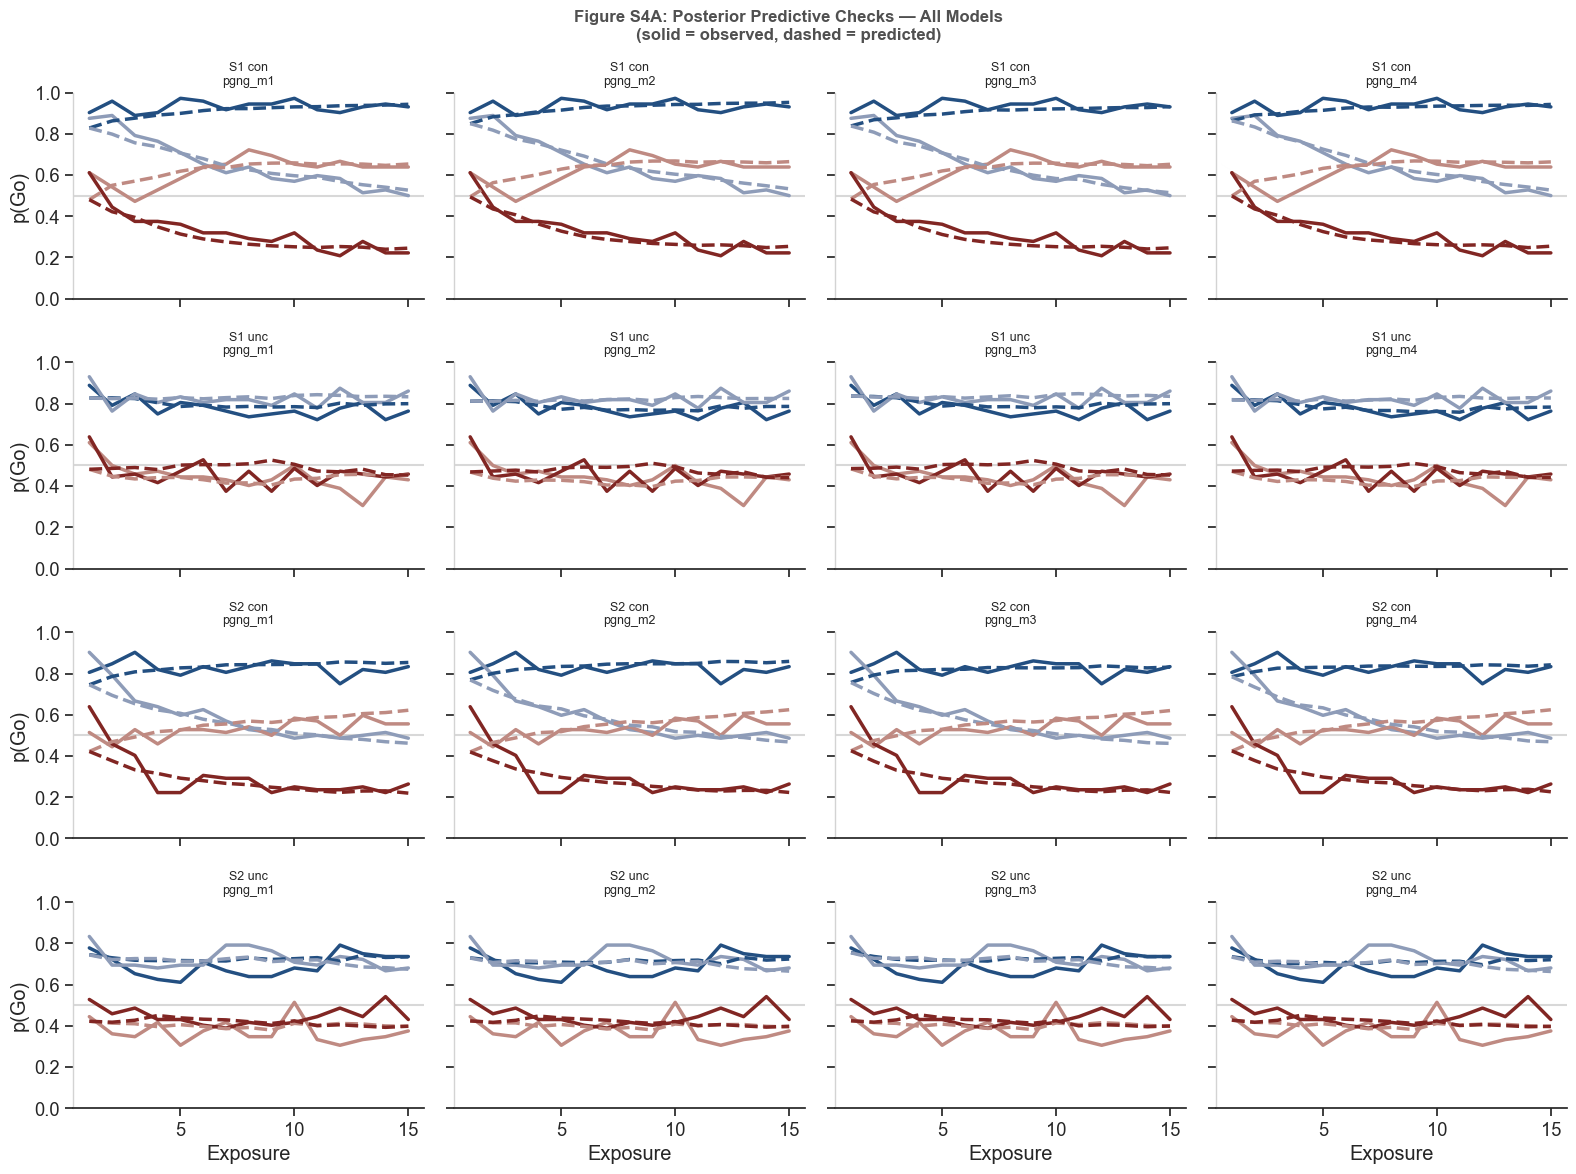

Saved figS4A


In [10]:
palette_lc = ['#234f81', '#8e9cb8', '#bf8a82', '#812623']
hue_order  = ['gw', 'ngw', 'gal', 'ngal']
conds      = ['controllable', 'uncontrollable']

fig, axes = plt.subplots(len(sessions)*2, len(models),
                         figsize=(len(models)*4, len(sessions)*6),
                         sharex=True, sharey=True)
fig.patch.set_facecolor('white')

for i, s in enumerate(sessions):
    for k, cond in enumerate(conds):
        row = i*2 + k
        for j, m in enumerate(models):
            ax  = axes[row, j]
            ppc = read_csv(os.path.join(RESULTS_DIR, s, f'{m}_ppc.csv'))
            sub = ppc[ppc['controllability']==cond]
            sns.lineplot(x='exposure', y='choice', hue='robot_type', data=sub,
                         hue_order=hue_order, palette=palette_lc,
                         lw=2.5, errorbar=None, legend=False, ax=ax)
            sns.lineplot(x='exposure', y='Y_hat', hue='robot_type', data=sub,
                         hue_order=hue_order, palette=palette_lc,
                         lw=2.5, errorbar=None, linestyle='--', legend=False, ax=ax)
            ax.axhline(0.5, color='0.5', alpha=0.3, zorder=-10)
            ax.set_title(f'{s.upper()} {cond[:3]}\n{m}', fontsize=9)
            ax.set_xlabel('Exposure')
            ax.set_ylabel('p(Go)') if j==0 else ax.set_ylabel('')
            ax.set_ylim(0, 1)
            ax.spines['left'].set(linewidth=1, color=axiscolor)
            sns.despine(ax=ax, left=False, right=True, top=True, bottom=False)

plt.suptitle('Figure S4A: Posterior Predictive Checks — All Models\n(solid = observed, dashed = predicted)',
             color=labelcolor, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'figS4A_ppc_all_models.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved figS4A')

## 7 — Figure S4B: Posterior Predictive Checks — M4

In [11]:
# Summary statistics
RMSE = lambda x: np.sqrt(np.mean(np.square(x)))
print('PPC fit statistics (M4):')
for s in sessions:
    for cond in conds:
        ppc = read_csv(os.path.join(RESULTS_DIR, s, f'{MODEL}_ppc.csv'))
        sub = ppc[ppc['controllability']==cond]
        gb  = sub.groupby(['subject','robot_type']).agg({'choice':'mean','Y_hat':'mean'}).reset_index()
        rmse = RMSE(gb.choice - gb.Y_hat)
        corr = gb[['choice','Y_hat']].corr().values[0,1]
        print(f'  {s.upper()} {cond[:3]}: RMSE={rmse:.3f}, r={corr:.3f}')

PPC fit statistics (M4):
  S1 con: RMSE=0.045, r=0.990
  S1 unc: RMSE=0.054, r=0.981
  S2 con: RMSE=0.045, r=0.988
  S2 unc: RMSE=0.080, r=0.949


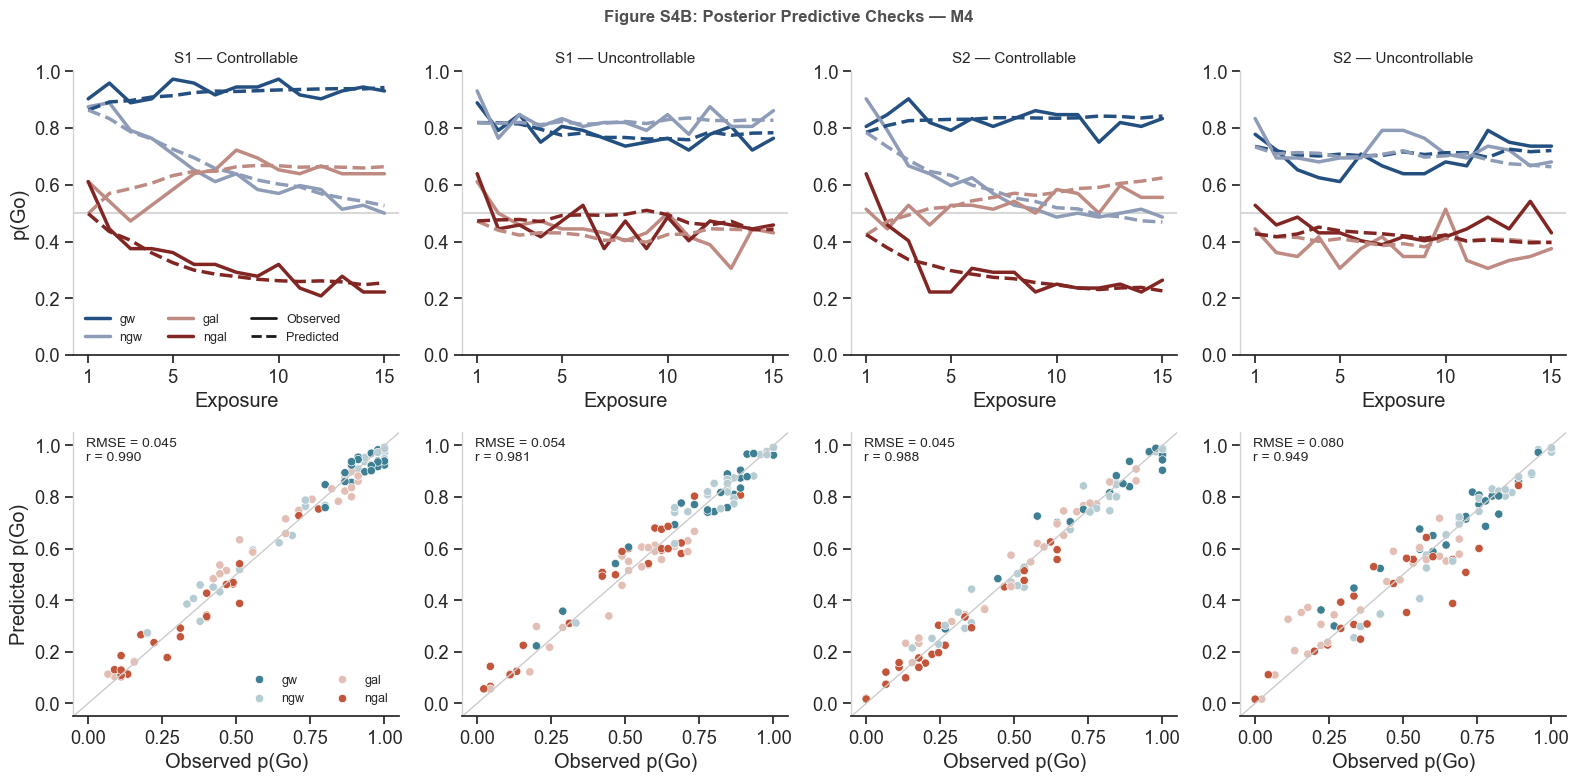

Saved figS4B


In [12]:
palette_sc = sns.diverging_palette(220, 20, n=4)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.patch.set_facecolor('white')

col = 0
for s in sessions:
    for cond in conds:
        # Row 0: learning curves
        ax  = axes[0, col]
        ppc = read_csv(os.path.join(RESULTS_DIR, s, f'{MODEL}_ppc.csv'))
        sub = ppc[ppc['controllability']==cond]
        sns.lineplot(x='exposure', y='choice', hue='robot_type', data=sub,
                     hue_order=hue_order, palette=palette_lc,
                     lw=2.5, errorbar=None, ax=ax, legend=(col==0))
        sns.lineplot(x='exposure', y='Y_hat', hue='robot_type', data=sub,
                     hue_order=hue_order, palette=palette_lc,
                     lw=2.5, errorbar=None, linestyle='--', ax=ax, legend=False)
        ax.axhline(0.5, color='0.5', alpha=0.3, zorder=-10)
        ax.set_title(f'{"S1" if s=="s1" else "S2"} — {cond.capitalize()}', fontsize=11)
        ax.set_xlabel('Exposure')
        ax.set_ylabel('p(Go)') if col==0 else ax.set_ylabel('')
        ax.set_ylim(0, 1)
        ax.set_xticks([1, 5, 10, 15])
        ax.spines['left'].set(linewidth=1, color=axiscolor)
        sns.despine(ax=ax, left=False, right=True, top=True, bottom=False)

        if col == 0:
            handles, lbls = ax.get_legend_handles_labels()
            handles += [Line2D([0],[0], color='k', lw=2, label='Observed'),
                        Line2D([0],[0], color='k', lw=2, ls='--', label='Predicted')]
            ax.legend(handles=handles, labels=lbls+['Observed','Predicted'],
                      frameon=False, fontsize=9, ncol=3, loc='lower left')

        # Row 1: scatter
        ax  = axes[1, col]
        gb  = sub.groupby(['subject','robot_type']).agg({'choice':'mean','Y_hat':'mean'}).reset_index()
        rmse = RMSE(gb.choice - gb.Y_hat)
        corr = gb[['choice','Y_hat']].corr().values[0,1]
        sns.scatterplot(x='choice', y='Y_hat', hue='robot_type', data=gb,
                        hue_order=hue_order, palette=palette_sc,
                        ax=ax, legend=(col==0))
        ax.plot([-0.05,1.05], [-0.05,1.05], color='0.8', lw=1)
        ax.set(xlim=(-0.05,1.05), ylim=(-0.05,1.05))
        ax.set_xlabel('Observed p(Go)')
        ax.set_ylabel('Predicted p(Go)') if col==0 else ax.set_ylabel('')
        ax.annotate(f'RMSE = {rmse:.3f}\nr = {corr:.3f}',
                    (0,0), (0.04, 0.98), 'axes fraction',
                    ha='left', va='top', fontsize=10)
        ax.spines['left'].set(linewidth=1, color=axiscolor)
        sns.despine(ax=ax, left=False, right=True, top=True, bottom=False)
        if col == 0:
            ax.legend(loc='lower right', frameon=False, ncol=2, fontsize=9)
        elif ax.get_legend():
            ax.get_legend().remove()

        col += 1

plt.suptitle('Figure S4B: Posterior Predictive Checks — M4',
             color=labelcolor, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'figS4B_ppc_m4.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'figS4B_ppc_m4.pdf'), bbox_inches='tight')
plt.show()
print('Saved figS4B')

## 8 — Reliability Summary

In [13]:
print('=== Split-half reliability (average across sessions) ===')
sh_avg = rel[(rel['Type']=='sh')&(rel['Group']==0)]
sh_avg = sh_avg.set_index('Param').loc[[p for p in params_order if p in sh_avg.index]]
for param, row in sh_avg.iterrows():
    print(f'  {param_names[param]:4s}: r={row["Mean"]:.3f} [{row["2.5%"]:.3f}, {row["97.5%"]:.3f}]')

print('\n=== Split-half reliability (by session) ===')
for g, label in [(1,'S1'),(2,'S2')]:
    print(f'  [{label}]')
    sh_s = rel[(rel['Type']=='sh')&(rel['Group']==g)]
    for param in params_order:
        row = sh_s[sh_s['Param']==param]
        if len(row)==0: continue
        r, lb, ub = row['Mean'].values[0], row['2.5%'].values[0], row['97.5%'].values[0]
        print(f'    {param_names[param]:4s}: r={r:.3f} [{lb:.3f}, {ub:.3f}]')

print('\n=== Test-retest reliability ===')
trt = rel[(rel['Type']=='trt')&(rel['Group']==0)]
for param in params_order:
    row = trt[trt['Param']==param]
    if len(row)==0: continue
    r, lb, ub = row['Mean'].values[0], row['2.5%'].values[0], row['97.5%'].values[0]
    print(f'  {param_names[param]:4s}: r={r:.3f} [{lb:.3f}, {ub:.3f}]')

=== Split-half reliability (average across sessions) ===

=== Split-half reliability (by session) ===
  [S1]
    β+  : r=0.354 [-0.024, 0.599]
    β−  : r=0.376 [0.056, 0.653]
    η+  : r=0.773 [0.613, 0.895]
    η−  : r=0.217 [-0.087, 0.521]
    τ+  : r=0.158 [-0.188, 0.495]
    τ−  : r=0.289 [-0.229, 0.662]
    δ+  : r=-0.188 [-0.469, 0.103]
    δ−  : r=-0.284 [-0.557, 0.096]
    ξ   : r=0.102 [-0.266, 0.565]
  [S2]
    β+  : r=0.172 [-0.185, 0.544]
    β−  : r=0.637 [0.367, 0.829]
    η+  : r=0.456 [-0.067, 0.792]
    η−  : r=0.588 [0.102, 0.838]
    τ+  : r=0.354 [0.109, 0.590]
    τ−  : r=0.075 [-0.348, 0.661]
    δ+  : r=-0.202 [-0.488, 0.047]
    δ−  : r=0.303 [-0.059, 0.634]
    ξ   : r=0.587 [0.342, 0.777]

=== Test-retest reliability ===
  β+  : r=0.223 [-0.091, 0.499]
  β−  : r=0.353 [0.184, 0.666]
  η+  : r=0.107 [-0.234, 0.499]
  η−  : r=-0.070 [-0.328, 0.356]
  τ+  : r=0.227 [-0.061, 0.491]
  τ−  : r=0.226 [-0.205, 0.753]
  δ+  : r=-0.378 [-0.641, -0.090]
  δ−  : r=-0.118

## 9 — Figure 5A: Group-Level Parameter Estimates

In [14]:
# Summary
print('Group-level parameter estimates (M4):')
for param in params_order:
    mu1, lb1, ub1 = get_group_ci(samp_s1, param)
    mu2, lb2, ub2 = get_group_ci(samp_s2, param)
    if np.isnan(mu1): continue
    print(f'  {param_names[param]:4s}: S1={mu1:.3f} [{lb1:.3f},{ub1:.3f}], S2={mu2:.3f} [{lb2:.3f},{ub2:.3f}]')

Group-level parameter estimates (M4):
  β+  : S1=9.821 [5.434,15.658], S2=8.818 [3.633,15.397]
  β−  : S1=7.899 [3.881,13.831], S2=7.736 [3.624,13.510]
  η+  : S1=0.111 [0.059,0.171], S2=0.143 [0.044,0.273]
  η−  : S1=0.118 [0.027,0.268], S2=0.102 [0.027,0.218]
  τ+  : S1=3.025 [2.113,4.152], S2=2.924 [1.570,4.931]
  τ−  : S1=-0.079 [-0.637,0.472], S2=-0.604 [-1.482,0.151]
  δ+  : S1=-0.290 [-1.092,0.596], S2=-0.377 [-1.165,0.435]
  δ−  : S1=-0.208 [-0.616,0.183], S2=0.014 [-0.402,0.419]
  ξ   : S1=0.040 [0.008,0.081], S2=0.067 [0.003,0.164]


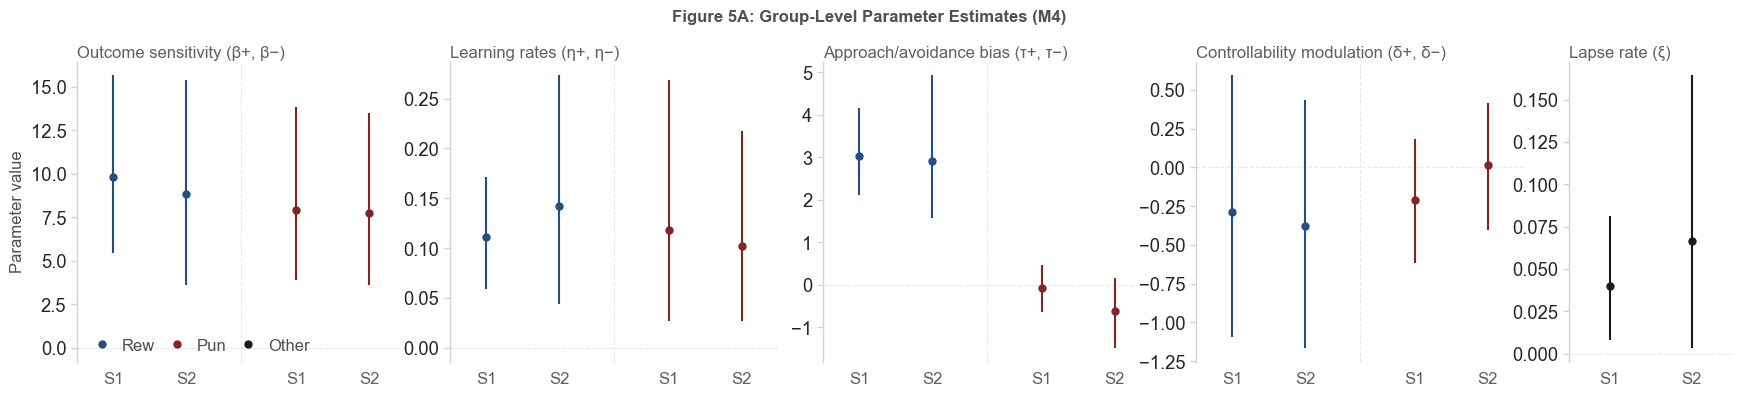

In [25]:
N_GROUPS = len(GROUPS)
fig, axes = plt.subplots(1, N_GROUPS, figsize=(18, 4),
                         gridspec_kw={'width_ratios': [2, 2, 2, 2, 1]})
fig.patch.set_facecolor('white')

for k, (title, param_list) in enumerate(GROUPS):
    ax = axes[k]
    if len(param_list) == 2:
        x_positions = {param_list[0]: [0, 1], param_list[1]: [2.5, 3.5]}
        xlim, xticks = (-0.5, 4.0), [0, 1, 2.5, 3.5]
        xticklabels  = ['S1', 'S2', 'S1', 'S2']
    else:
        x_positions = {param_list[0]: [0, 1]}
        xlim, xticks = (-0.5, 1.5), [0, 1]
        xticklabels  = ['S1', 'S2']

    for param in param_list:
        color = PARAM_COLOR[param]
        mu1, lb1, ub1 = get_group_ci(samp_s1, param)
        mu2, lb2, ub2 = get_group_ci(samp_s2, param)
        xs = x_positions[param]
        ax.errorbar(xs, [mu1, mu2],
                    yerr=[[mu1-lb1, mu2-lb2], [ub1-mu1, ub2-mu2]],
                    fmt='o', color=color, ms=5, capsize=0, elinewidth=1.5, zorder=3)

    if len(param_list) == 2:
        ax.axvline(1.75, color=axiscolor, lw=0.8, ls='--', alpha=0.5)
    ax.axhline(0, color=axiscolor, lw=0.8, ls='--', alpha=0.5)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, color=tickcolor, fontsize=12)
    ax.set_xlim(xlim)
    ax.set_title(title, loc='left', color=tickcolor, fontsize=12, pad=3)
    ax.spines['left'].set(linewidth=1, color=axiscolor)
    ax.tick_params(bottom=False, left=True, color=axiscolor, length=4, width=1)
    sns.despine(ax=ax, left=False, right=True, top=True, bottom=True)

    if k == 0:
        ax.set_ylabel('Parameter value', color=labelcolor, fontsize=12)
        legend_handles = [
            Line2D([0],[0], color=COLOR_REW, marker='o', ms=5, lw=0, label='Rew'),
            Line2D([0],[0], color=COLOR_PUN, marker='o', ms=5, lw=0, label='Pun'),
            Line2D([0],[0], color='k',       marker='o', ms=5, lw=0, label='Other'),
        ]
        ax.legend(handles=legend_handles, loc='lower left', frameon=False,
                  labelcolor=labelcolor, fontsize=12, ncol=3,
                  columnspacing=0.3, handletextpad=0.2,
                  borderpad=0)

plt.suptitle('Figure 5A: Group-Level Parameter Estimates (M4)', color=labelcolor,
             fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.15, top=0.85, bottom=0.1, left=0.06, right=0.98)
plt.savefig(os.path.join(FIG_DIR, 'fig05A_param_estimates.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig05A_param_estimates.pdf'), bbox_inches='tight')
plt.show()

## 10 — Figure 5B: Split-Half Reliability

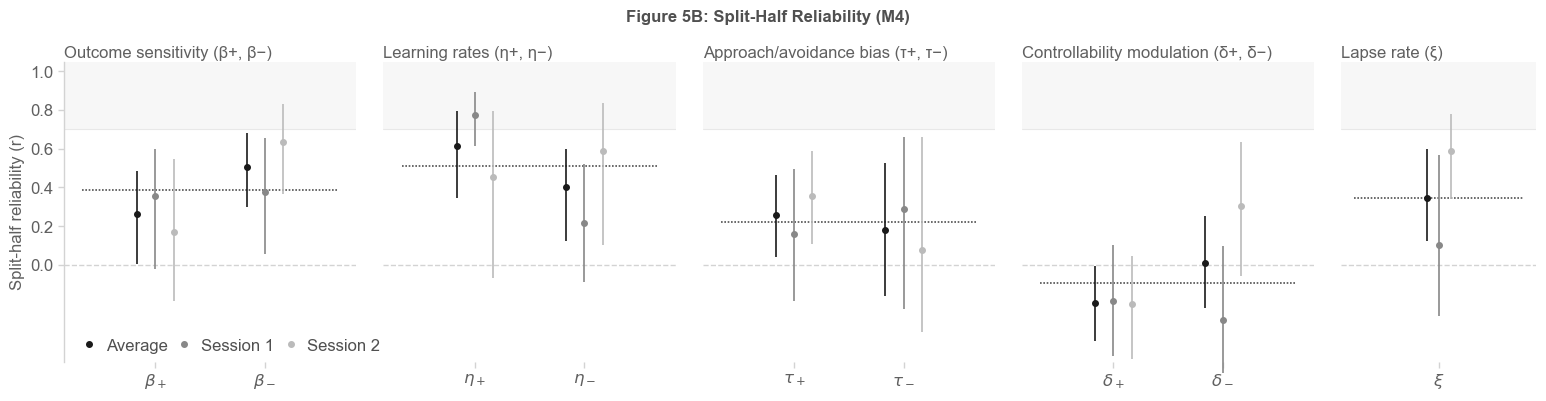

Saved fig05B


In [32]:
sh_colors = ['k', '#888888', '#bbbbbb']
offsets2  = [-0.15, 0.15]
fig, axes = plt.subplots(1, N_GROUPS, figsize=(16, 4),
                         gridspec_kw={'width_ratios': [1.5, 1.5, 1.5, 1.5, 1]})
fig.patch.set_facecolor('white')

for k, (title, param_list) in enumerate(GROUPS):
    ax = axes[k]
    ax.fill_betweenx([0.7, 1.05], -0.4, 0.4, color=axiscolor, alpha=0.18, lw=0)
    ax.axhline(0, color=axiscolor, lw=1.0, ls='--')
    ax.axhline(0.7, color=axiscolor, lw=0.8, ls='-', alpha=0.5)
    offs = offsets2[:len(param_list)] if len(param_list)==2 else [0.0]
    rhos = []
    for param, off in zip(param_list, offs):
        for g, sh_color in enumerate(sh_colors):
            r, lb, ub = get_reliability(rel, param, 'sh', group=g)
            if np.isnan(r): continue
            if g == 0: rhos.append(r)
            x_g  = off + (g-1)*0.05
            yerr = [[r-lb],[ub-r]] if not np.isnan(lb) else None
            ax.errorbar(x_g, r, yerr=yerr, fmt='o', color=sh_color,
                        ms=4, elinewidth=1.2, capsize=0, zorder=4, clip_on=False)
    if rhos:
        ax.hlines(np.mean(rhos), -0.35, 0.35, color=COLOR_AVG, lw=1.2,
                  linestyle=(0,(1,1)), zorder=2)
    ax.set_xticks(offs)
    ax.set_xticklabels([param_labels[p] for p in param_list], color=tickcolor, fontsize=12)
    ax.set_xlim(-0.4, 0.4)
    ax.set_ylim(-0.5, 1.05)
    ax.set_title(title, loc='left', color=tickcolor, fontsize=12, pad=3)
    ax.spines['left'].set(linewidth=1, color=axiscolor)
    ax.tick_params(color=axiscolor, length=4, width=1)
    if k == 0:
        ax.set_yticks(np.linspace(0, 1, 6))
        ax.set_yticklabels([f'{v:.1f}' for v in np.linspace(0,1,6)], color=tickcolor, fontsize=12)
        ax.set_ylabel('Split-half reliability (r)', color=tickcolor, fontsize=12)
        sns.despine(ax=ax, left=False, right=True, top=True, bottom=True)
        ax.tick_params(bottom=True, left=True)
        legend_handles = [
            Line2D([0],[0], color=sh_colors[0], marker='o', ms=4, lw=0, label='Average'),
            Line2D([0],[0], color=sh_colors[1], marker='o', ms=4, lw=0, label='Session 1'),
            Line2D([0],[0], color=sh_colors[2], marker='o', ms=4, lw=0, label='Session 2'),
        ]
        ax.legend(handles=legend_handles, loc='lower left', frameon=False,
                  labelcolor=labelcolor, fontsize=12, ncol=3,
                  columnspacing=0, handletextpad=0,
                  borderpad=0)
    else:
        sns.despine(ax=ax, left=True, right=True, top=True, bottom=True)
        ax.tick_params(bottom=True, left=False)
        ax.set_yticklabels([])

plt.suptitle('Figure 5B: Split-Half Reliability (M4)', color=labelcolor,
             fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.1, top=0.85, bottom=0.1, left=0.06, right=0.98)
plt.savefig(os.path.join(FIG_DIR, 'fig05B_splithalf.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig05B_splithalf.pdf'), bbox_inches='tight')
plt.show()
print('Saved fig05B')

## 11 — Figure 5C: Test-Retest Reliability

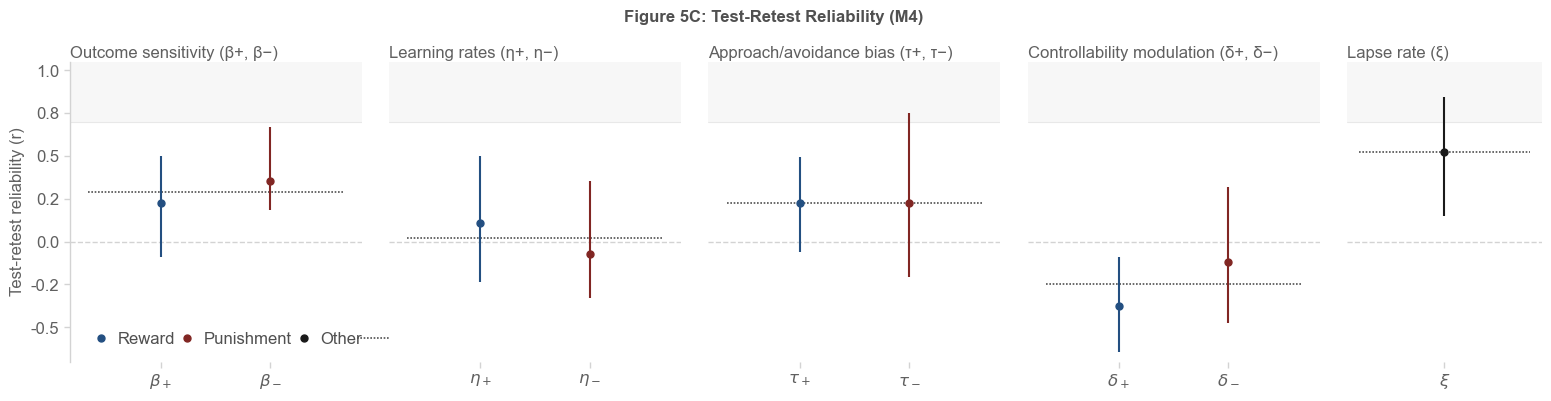

Saved fig05C


In [40]:
fig, axes = plt.subplots(1, N_GROUPS, figsize=(16, 4),
                         gridspec_kw={'width_ratios': [1.5, 1.5, 1.5, 1.5, 1]})
fig.patch.set_facecolor('white')

for k, (title, param_list) in enumerate(GROUPS):
    ax = axes[k]
    ax.fill_betweenx([0.7, 1.05], -0.4, 0.4, color=axiscolor, alpha=0.18, lw=0)
    ax.axhline(0, color=axiscolor, lw=1.0, ls='--')
    ax.axhline(0.7, color=axiscolor, lw=0.8, ls='-', alpha=0.5)
    offs = offsets2[:len(param_list)] if len(param_list)==2 else [0.0]
    rhos = []
    for param, off in zip(param_list, offs):
        color     = PARAM_COLOR[param]
        r, lb, ub = get_reliability(rel, param, 'trt', group=0)
        if np.isnan(r): continue
        rhos.append(r)
        yerr = [[r-lb],[ub-r]] if not np.isnan(lb) else None
        ax.errorbar(off, r, yerr=yerr, fmt='o', color=color,
                    ms=5, elinewidth=1.5, capsize=0, zorder=4, clip_on=False)
    if rhos:
        ax.hlines(np.mean(rhos), -0.35, 0.35, color=COLOR_AVG, lw=1.2,
                  linestyle=(0,(1,1)), zorder=2)
    ax.set_xticks(offs)
    ax.set_xticklabels([param_labels[p] for p in param_list], color=tickcolor, fontsize=12)
    ax.set_xlim(-0.4, 0.4)
    ax.set_ylim(-0.7, 1.05)
    ax.set_title(title, loc='left', color=tickcolor, fontsize=12, pad=3)
    ax.spines['left'].set(linewidth=1, color=axiscolor)
    ax.tick_params(color=axiscolor, length=4, width=1)
    if k == 0:
        ax.set_yticks(np.linspace(-0.5, 1, 7))
        ax.set_yticklabels([f'{v:.1f}' for v in np.linspace(-0.5,1,7)], color=tickcolor, fontsize=12)
        ax.set_ylabel('Test-retest reliability (r)', color=tickcolor, fontsize=12)
        sns.despine(ax=ax, left=False, right=True, top=True, bottom=True)
        ax.tick_params(bottom=True, left=True)
        legend_handles = [
            Line2D([0],[0], color=COLOR_REW, marker='o', ms=5, lw=0, label='Reward'),
            Line2D([0],[0], color=COLOR_PUN, marker='o', ms=5, lw=0, label='Punishment'),
            Line2D([0],[0], color='k',       marker='o', ms=5, lw=0, label='Other'),
            Line2D([0],[0], color=COLOR_AVG, lw=1.2, ls=(0,(1,1)), label='Average'),
        ]
        ax.legend(handles=legend_handles, loc='lower left', frameon=False,
                  labelcolor=labelcolor, fontsize=12, ncol=4,
                  columnspacing=-0.3, handletextpad=0)
    else:
        sns.despine(ax=ax, left=True, right=True, top=True, bottom=True)
        ax.tick_params(bottom=True, left=False)
        ax.set_yticklabels([])

plt.suptitle('Figure 5C: Test-Retest Reliability (M4)', color=labelcolor,
             fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.1, top=0.85, bottom=0.1, left=0.06, right=0.98)
plt.savefig(os.path.join(FIG_DIR, 'fig05C_testretest.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig05C_testretest.pdf'), bbox_inches='tight')
plt.show()
print('Saved fig05C')